### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _03_01_function_to_normalize_sgrna_lfc import *

#### Process Avana LFC and library data

In [8]:
lfc_data = pd.read_csv("../data/sgrna_lfc_data/avana_data/AvanaLogfoldChange_25Q2.csv")
lfc_data = lfc_data.rename(columns={lfc_data.columns[0]: 'spacer'})

# select specific columns
lfc_data = lfc_data.iloc[:, :3]
lfc_data.head(25)

,spacer,Colo699-311cas9-RepA-p6_Avana-4,Colo699-311cas9-RepB-p6_Avana-4
0,AAAAAAATCCAGCAATGCAG,-0.171066,0.029490
1,AAAAAACCCGTAGATAGCCT,-0.402138,-0.307266
2,AAAAAAGAAGAAAAAACCAG,-0.410449,-0.612478
3,AAAAAAGCTCAAGAAGGAGG,-0.391271,-0.523115
4,AAAAAAGGCTGTAAAAGCGT,-0.529545,-0.078421
5,AAAAAAGGGCTCCAAAAAGG,-0.597079,0.196256
6,AAAAACAACACATCAGAGCG,0.381416,-0.204037
7,AAAAACTCTGGGAAATGACT,0.334391,0.231206
8,AAAAAGACAACCTCGCCCTG,0.108744,0.099787
9,AAAAAGAGCTGTTTGAACAA,-0.084525,0.066873


In [9]:
library_data = pd.read_csv("../data/library_data/avana_library.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
library_data.shape

(71826, 3)

In [10]:
lfc = pd.merge(lfc_data, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="gene")
lfc

Colo699-311cas9-RepA-p6_Avana-4  \
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.257686   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.233408   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                         0.023756   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                         0.014280   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                         0.054652   
...                                                             ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                         -0.347602   
         TTTTACCTTGTTCACATGGA NaN                          0.085937   
         TTTTGACTCTAATCACCGGT NaN                          0.004612   
         TTTTTAATACAAGGTAATCT NaN                         -0.007124   
         TTTTTCTCACCCGATGAATC NaN                          0.033292   

                                    Colo699-311cas9-RepB-p6_Avana-4  
sgRNA    spacer               gene                                   
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.298174  
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.299895  
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                        -0.473843  
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                        -0.324734  
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                        -0.087523  
...                                                             ...  
NaN      TTTGTGTATTACCTCAGGAA NaN                          0.320081  
         TTTTACCTTGTTCACATGGA NaN                          0.292619  
         TTTTGACTCTAATCACCGGT NaN                         -0.385894  
         TTTTTAATACAAGGTAATCT NaN                          0.154439  
         TTTTTCTCACCCGATGAATC NaN                         -0.138348  

[76427 rows x 2 columns]

In [11]:
# normalize data by median
lfc_norm = lfc.apply(normalize_column, axis=0)

Scale factor:  0.8364954714036925


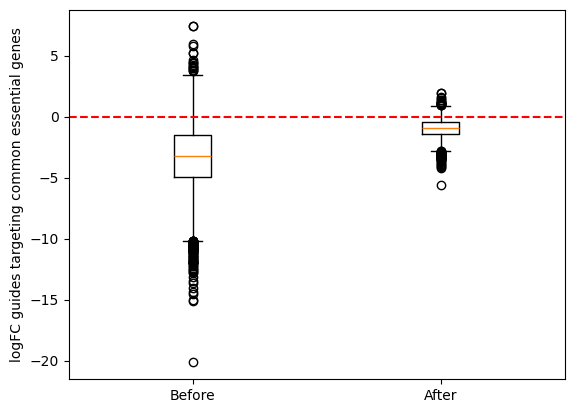

In [12]:
lfc_norm_scaled, list_common_essential = scale_essential(lfc)
sanity_check_scale_essential(lfc_norm, lfc_norm_scaled, list_common_essential)


In [13]:
lfc_norm_scaled_avg = mean_row(lfc_norm_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,GGAAGTCTGGAGTCTCCAGG,A1BG,-0.332255
1,sgA1BG_2,GTGGACTTCCAGCTACGGCG,A1BG,0.318772
2,sgA1BG_4,TCAATGGTCACAGTAGCGCT,A1BG,-0.269032
3,sgA1BG_3,GTGTGCCGAGGTGTGCTGCG,A1BG,-0.185569
4,sgA1CF_2,GGAATCAAATCACAAATCCG,A1CF,-0.019648
...,...,...,...,...
76422,NaN,TTTGTGTATTACCTCAGGAA,NaN,-0.016450
76423,NaN,TTTTACCTTGTTCACATGGA,NaN,0.226275
76424,NaN,TTTTGACTCTAATCACCGGT,NaN,-0.227905
76425,NaN,TTTTTAATACAAGGTAATCT,NaN,0.088055


In [ ]:
lfc_norm_scaled_avg.to_csv("../data/sgrna_lfc_data/output_normalized/avana_normalized_lfc.csv", index=False)